# Phase 1 - Linear Regression



## 1. Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the dataset

In [5]:
import pandas as pd

df = pd.read_excel("../student_placement_phase1_ready.xlsx")

df.head()

,college_pursuing_year,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,placement_status
0,4,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,72.647009,77.463863,2,63.382726,52.938240,Yes,Not Placed
1,4,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,61.699110,88.887600,1,73.694605,60.198856,No,Not Placed
2,4,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,87.396911,74.153265,0,63.329294,43.708803,No,Placed
3,4,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,58.401069,87.635955,1,47.636099,56.549154,Yes,Not Placed
4,3,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,74.489201,79.120749,1,0.000000,67.268893,No,Placed


In [6]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (100000, 20)
Missing values: 0
Duplicate rows: 0


## 3. Check placement status

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


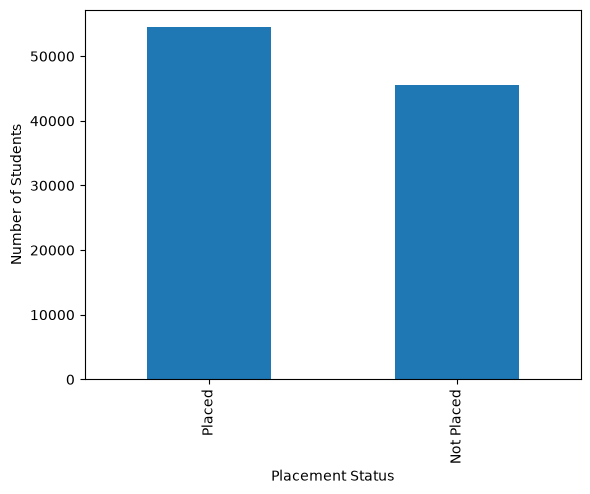

In [7]:
print(df["placement_status"].value_counts())

df["placement_status"].value_counts().plot(kind="bar")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

## 4. Select features and target

In [8]:
features = [
    "college_pursuing_year", "cgpa", "branch", "college_tier",
    "internships_count", "projects_count", "certifications_count",
    "coding_skill_score", "aptitude_score", "communication_skill_score",
    "logical_reasoning_score", "hackathons_participated", "github_repos",
    "mock_interview_score", "attendance_percentage", "backlogs",
    "extracurricular_score", "leadership_score", "volunteer_experience"
]

X = df[features]
y = df["placement_status"]

## 5. Convert target into numbers

Not Placed = 0, Placed = 1

In [9]:
y = y.map({"Not Placed": 0, "Placed": 1})

print(y.head())

0    0
1    0
2    1
3    0
4    1
Name: placement_status, dtype: int64


## 6. Convert categorical columns into numbers

Linear Regression cannot directly use text values, so we use one-hot encoding.

In [10]:
X = pd.get_dummies(X, columns=[
    "branch", "college_tier", "volunteer_experience"
], drop_first=True)

X = X.astype(float)
X_columns = X.columns

print(X.shape)

(100000, 24)


## 7. Split training and testing data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 24)
Testing data: (20000, 24)


## 8. Scale the features

Fit the scaler only on training data to avoid data leakage.

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 9. Train Linear Regression

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 10. Evaluate the model

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.48453893753379534
MSE : 0.24249654438901758
RMSE: 0.49243938143594645
R2  : 0.022564503065497732


## 11. Get feature weights

In [15]:
weights = pd.DataFrame({
    "Feature": X_columns,
    "Weight": model.coef_
})

weights = weights.sort_values("Weight", ascending=False)
weights

,Feature,Weight
2,internships_count,0.032003
3,projects_count,0.030815
5,coding_skill_score,0.025690
11,mock_interview_score,0.022077
7,communication_skill_score,0.017131
8,logical_reasoning_score,0.016379
6,aptitude_score,0.015710
15,leadership_score,0.011114
14,extracurricular_score,0.009836
1,cgpa,0.006712


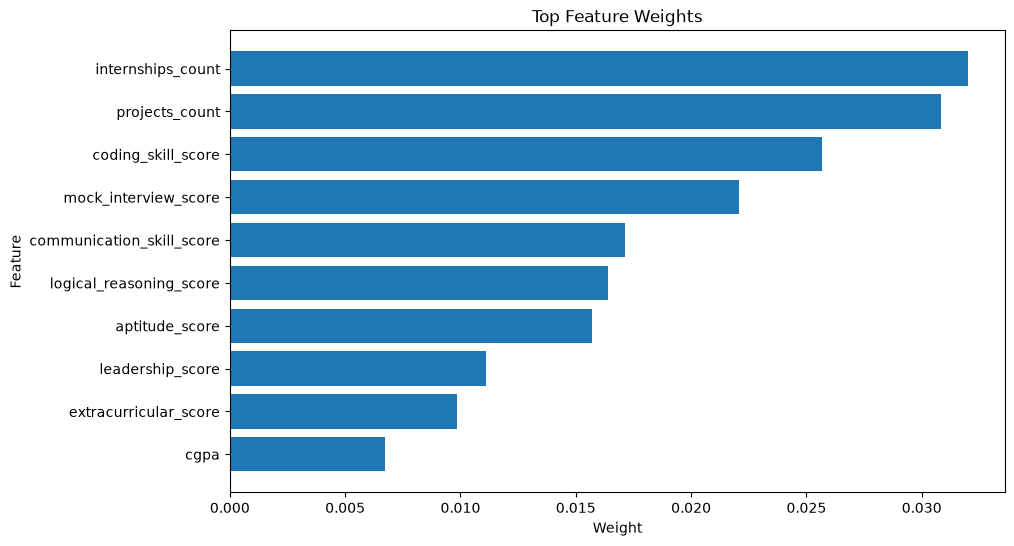

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(weights.head(10)["Feature"], weights.head(10)["Weight"])
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.title("Top Feature Weights")
plt.gca().invert_yaxis()
plt.show()

## 12. Actual vs Predicted

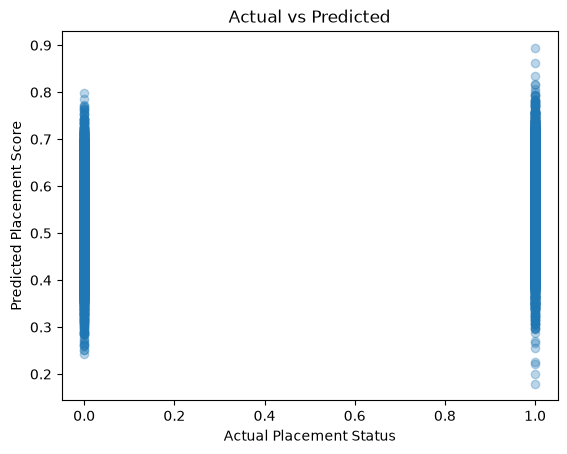

In [17]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Placement Status")
plt.ylabel("Predicted Placement Score")
plt.title("Actual vs Predicted")
plt.show()

## 13. Save feature weights

In [18]:
weights.to_csv("feature_weights_linear_regression.csv", index=False)
print("Feature weights saved successfully.")

Feature weights saved successfully.
